# Lennard-Jones MD Performance

Compare the dense all-pairs force path with the cell-list neighbor path.

In [1]:
import matplotlib.pyplot as plt

from mlx_atomistic.benchmarks.lj_md import run_case

particle_counts = [32, 64, 128]
results = []
for particles in particle_counts:
    for mode in ("all-pairs", "neighbor"):
        results.append(
            run_case(
                particles=particles,
                steps=10,
                mode=mode,
                density=0.8,
                temperature=1.0,
                seed=7,
            )
        )

results

[BenchmarkResult(mode='all-pairs', particles=32, steps=10, pairs=None, ms_per_step=0.47779169981367886, energy_drift=0.2020263671875),
 BenchmarkResult(mode='neighbor', particles=32, steps=10, pairs=480, ms_per_step=1.3201624969951808, energy_drift=0.2020263671875),
 BenchmarkResult(mode='all-pairs', particles=64, steps=10, pairs=None, ms_per_step=0.32638749689795077, energy_drift=0.32492828369140625),
 BenchmarkResult(mode='neighbor', particles=64, steps=10, pairs=1876, ms_per_step=0.36654589930549264, energy_drift=0.3249664306640625),
 BenchmarkResult(mode='all-pairs', particles=128, steps=10, pairs=None, ms_per_step=1.3681790966074914, energy_drift=1.3782958984375),
 BenchmarkResult(mode='neighbor', particles=128, steps=10, pairs=5440, ms_per_step=0.3832707996480167, energy_drift=1.3782958984375)]

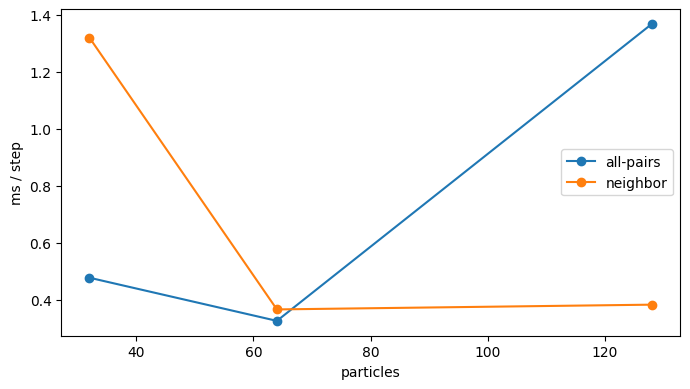

In [2]:
plt.figure(figsize=(7, 4))
for mode in ("all-pairs", "neighbor"):
    xs = [result.particles for result in results if result.mode == mode]
    ys = [result.ms_per_step for result in results if result.mode == mode]
    plt.plot(xs, ys, marker="o", label=mode)

plt.xlabel("particles")
plt.ylabel("ms / step")
plt.legend()
plt.tight_layout()